100%|██████████| 499M/499M [00:08<00:00, 60.1MB/s]

Extracting files...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


✅ Dataset loaded: 10175 images | Size: 256x256 | Batch: 8


/tmp/ipykernel_556/2679158545.py:162: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


...

✅ Epoch [3/5] | Avg Loss: 0.1046 | Time: 302.7 seconds



Epoch 4/5: 100%|██████████| 1272/1272 [05:01<00:00,  4.22it/s, Loss=0.0785]


✅ Epoch [4/5] | Avg Loss: 0.0908 | Time: 301.2 seconds



Epoch 5/5: 100%|██████████| 1272/1272 [05:02<00:00,  4.20it/s, Loss=0.0695]
/tmp/ipykernel_556/2679158545.py:203: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Epoch [5/5] | Avg Loss: 0.0822 | Time: 302.7 seconds



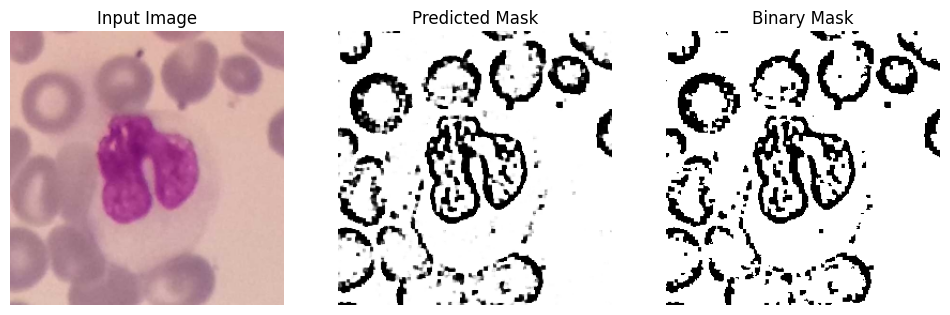

In [ ]:
import cv2
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub
from tqdm import tqdm
import time

# DiceLoss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds).view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2 * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.MaxPool2d(2)
        self.conv1 = DoubleConv(64, 128)
        self.down2 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(128, 256)
        self.down3 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(256, 512)
        self.down4 = nn.MaxPool2d(2)
        self.conv4 = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv5 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv6 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv7 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv8 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.conv1(self.down1(x1))
        x3 = self.conv2(self.down2(x2))
        x4 = self.conv3(self.down3(x3))
        x5 = self.conv4(self.down4(x4))

        x = self.up1(x5)
        x = F.interpolate(x, size=x4.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x4], dim=1)
        x = self.conv5(x)

        x = self.up2(x)
        x = F.interpolate(x, size=x3.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x3], dim=1)
        x = self.conv6(x)

        x = self.up3(x)
        x = F.interpolate(x, size=x2.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x2], dim=1)
        x = self.conv7(x)

        x = self.up4(x)
        x = F.interpolate(x, size=x1.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x1], dim=1)
        x = self.conv8(x)

        return self.outc(x)


# Mask Generator & Dataset
def create_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 11, 2)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask / 255.0


IMG_SIZE = 256

class WBCSegDataset(Dataset):
    def __init__(self, root_dir, img_size=IMG_SIZE):
        self.paths = []
        self.img_size = img_size
        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            if os.path.isdir(cls_path):
                for img_name in os.listdir(cls_path):
                    self.paths.append(os.path.join(cls_path, img_name))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = np.array(img)
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

        mask = create_mask(img)

        img = torch.tensor(img / 255.0).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()
        return img, mask


# =========================
# Load Dataset
# =========================
path = kagglehub.dataset_download("masoudnickparvar/white-blood-cells-dataset")
train_path = os.path.join(path, "Train")

train_dataset = WBCSegDataset(train_path, img_size=IMG_SIZE)
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"✅ Dataset loaded: {len(train_dataset)} images | Size: {IMG_SIZE}x{IMG_SIZE} | Batch: 8")

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_channels=3, n_classes=1).to(device)

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()
print(f"🚀 Training on: {device}\n")

# Training Loop with Progress Bar
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    epoch_start = time.time()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for images, masks in progress_bar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = bce_loss(outputs, masks) + dice_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(train_loader)
    epoch_time = time.time() - epoch_start

    print(f"✅ Epoch [{epoch+1}/{num_epochs}] | Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.1f} seconds\n")

# Visualization
def show_prediction(model, image_tensor):
    model.eval()
    with torch.no_grad():
        with autocast():
            pred = torch.sigmoid(model(image_tensor.unsqueeze(0).to(device)))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1); plt.title("Input Image"); plt.imshow(image_tensor.permute(1,2,0).cpu()); plt.axis("off")
    plt.subplot(1, 3, 2); plt.title("Predicted Mask"); plt.imshow(pred.squeeze().cpu(), cmap="gray"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.title("Binary Mask"); plt.imshow((pred.squeeze().cpu() > 0.5).float(), cmap="gray"); plt.axis("off")
    plt.show()

sample_img, _ = train_dataset[0]
show_prediction(model, sample_img)

In [ ]:
import torch

def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)


def iou_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = (pred + target - pred * target).sum()

    return (intersection + 1e-6) / (union + 1e-6)


def pixel_accuracy(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    correct = (pred == target).sum()
    total = torch.numel(pred)

    return correct / total

In [ ]:
def evaluate_model(model, loader, device):
    model.eval()

    dice_total = 0
    iou_total = 0
    acc_total = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            dice_total += dice_score(outputs, masks).item()
            iou_total += iou_score(outputs, masks).item()
            acc_total += pixel_accuracy(outputs, masks).item()

    n = len(loader)

    print(f"🔥 Dice Score: {dice_total/n:.4f}")
    print(f"🔥 IoU Score: {iou_total/n:.4f}")
    print(f"🔥 Pixel Accuracy: {acc_total/n:.4f}")

evaluate_model(model, train_loader, device)

🔥 Dice Score: 0.9838
🔥 IoU Score: 0.9681
🔥 Pixel Accuracy: 0.9757


In [ ]:
def show_with_metrics(model, dataset, idx=0):
    model.eval()

    image, mask = dataset[idx]

    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device))

    d = dice_score(pred, mask.unsqueeze(0).to(device)).item()
    i = iou_score(pred, mask.unsqueeze(0).to(device)).item()
    a = pixel_accuracy(pred, mask.unsqueeze(0).to(device)).item()

    pred_mask = torch.sigmoid(pred).squeeze().cpu()

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image.permute(1,2,0))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("True Mask")
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title(f"Pred Mask\nDice:{d:.2f} IoU:{i:.2f} Acc:{a:.2f}")
    plt.imshow(pred_mask, cmap="gray")
    plt.axis("off")

    plt.show()

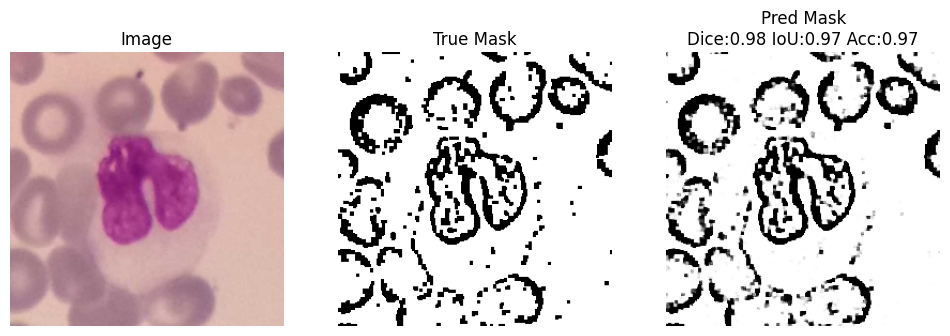

In [ ]:
show_with_metrics(model, train_dataset, idx=0)

💾 UNet saved for backend


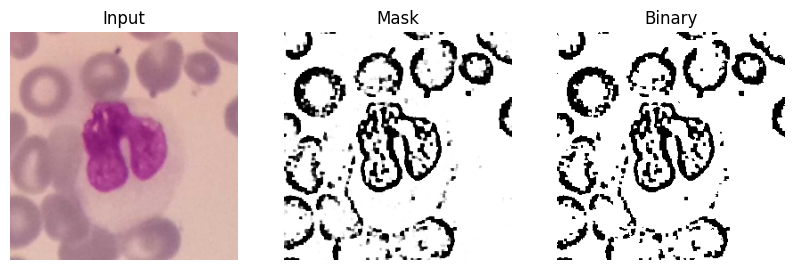

In [ ]:
# SAVE + EXPORT
import torch
import numpy as np
import cv2

# save model
torch.save(model.state_dict(), "unet_wbc.pth")
print("💾 UNet saved for backend")

# INFERENCE FUNCTION (ready for API)
def predict_mask(image_np):
    """
    image_np: numpy image (H,W,3) range [0,255]
    """
    model.eval()

    # preprocess
    img = cv2.resize(image_np, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))

    mask = pred.squeeze().cpu().numpy()
    binary_mask = (mask > 0.5).astype(np.uint8)

    return mask, binary_mask

# TEST FUNCTION (simulate backend usage)
sample_img, _ = train_dataset[0]
sample_np = sample_img.permute(1,2,0).numpy() * 255
sample_np = sample_np.astype(np.uint8)

mask, binary = predict_mask(sample_np)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(sample_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Binary")
plt.imshow(binary, cmap='gray')
plt.axis("off")

plt.show()

In [ ]:
from google.colab import files

files.download("unet_wbc.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>